開始訓練 TS-TCC 模型...
Epoch 1/50: Total Loss = 6.3566 (Temporal: 3.9189, Context: 3.4824)
Epoch 2/50: Total Loss = 5.3786 (Temporal: 3.5019, Context: 2.6810)
Epoch 3/50: Total Loss = 4.9688 (Temporal: 3.2811, Context: 2.4110)
Epoch 4/50: Total Loss = 4.7904 (Temporal: 3.1953, Context: 2.2787)
Epoch 5/50: Total Loss = 4.6324 (Temporal: 3.0926, Context: 2.1998)
Epoch 6/50: Total Loss = 4.4263 (Temporal: 2.9696, Context: 2.0810)
Epoch 7/50: Total Loss = 4.3439 (Temporal: 2.9065, Context: 2.0535)
Epoch 8/50: Total Loss = 4.1714 (Temporal: 2.7834, Context: 1.9828)
Epoch 9/50: Total Loss = 4.1656 (Temporal: 2.7939, Context: 1.9596)
Epoch 10/50: Total Loss = 4.1487 (Temporal: 2.7692, Context: 1.9708)
Epoch 11/50: Total Loss = 4.0402 (Temporal: 2.7089, Context: 1.9019)
Epoch 12/50: Total Loss = 3.9728 (Temporal: 2.6545, Context: 1.8832)
Epoch 13/50: Total Loss = 4.0212 (Temporal: 2.6860, Context: 1.9074)
Epoch 14/50: Total Loss = 3.9703 (Temporal: 2.6503, Context: 1.8858)
Epoch 15/50: Total Loss =

c:\Users\user\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


ValueError: Buffer dtype mismatch, expected 'double' but got 'float'

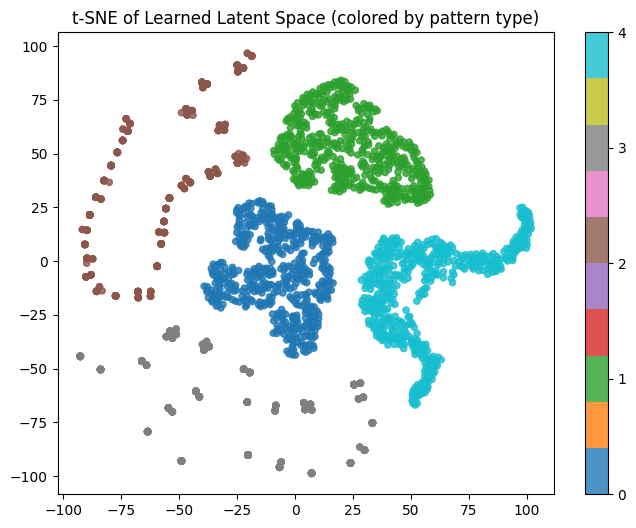

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import random

# ----------------------------
# 1. 資料模擬（同前）
# ----------------------------
def generate_sine_wave(T, freq=1.0, phase=0.0, amplitude=1.0):
    t = np.linspace(0, 2*np.pi, T)
    return amplitude * np.sin(freq * t + phase)

def generate_trend_sine(T, freq=1.0, phase=0.0, amplitude=1.0, trend=0.01):
    t = np.linspace(0, 2*np.pi, T)
    return amplitude * np.sin(freq * t + phase) + trend * np.arange(T)

def generate_square_wave(T, freq=1.0):
    t = np.linspace(0, 2*np.pi, T)
    return np.sign(np.sin(freq * t))

def generate_sawtooth_wave(T, period=50):
    return 2 * (np.arange(T) % period) / period - 1

def generate_random_walk(T):
    steps = np.random.normal(0, 0.2, T)
    return np.cumsum(steps)

class SimulatedTimeSeriesDataset(Dataset):
    def __init__(self, num_samples_per_class=500, T=128):
        self.data = []
        self.labels = []
        for _ in range(num_samples_per_class):
            freq = random.uniform(0.8, 1.2)
            phase = random.uniform(0, np.pi)
            amplitude = random.uniform(0.8, 1.2)
            ts = generate_sine_wave(T, freq, phase, amplitude)
            self.data.append(ts)
            self.labels.append(0)
        for _ in range(num_samples_per_class):
            freq = random.uniform(0.8, 1.2)
            phase = random.uniform(0, np.pi)
            amplitude = random.uniform(0.8, 1.2)
            trend = random.uniform(0.005, 0.02)
            ts = generate_trend_sine(T, freq, phase, amplitude, trend)
            self.data.append(ts)
            self.labels.append(1)
        for _ in range(num_samples_per_class):
            freq = random.uniform(0.8, 1.2)
            ts = generate_square_wave(T, freq)
            self.data.append(ts)
            self.labels.append(2)
        for _ in range(num_samples_per_class):
            period = random.randint(20, 40)
            ts = generate_sawtooth_wave(T, period)
            self.data.append(ts)
            self.labels.append(3)
        for _ in range(num_samples_per_class):
            ts = generate_random_walk(T)
            self.data.append(ts)
            self.labels.append(4)
        self.data = np.array(self.data)
        self.labels = np.array(self.labels)
        self.data = self.data[..., np.newaxis]
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        x = torch.tensor(self.data[idx], dtype=torch.float)
        label = self.labels[idx]
        return x, label

# ----------------------------
# 2. 資料增強函數（同前）
# ----------------------------
def weak_augmentation(x, jitter_std=0.05, scale_range=(0.9, 1.1)):
    noise = torch.randn_like(x) * jitter_std
    scale = torch.empty(x.size(0), 1, 1, device=x.device).uniform_(*scale_range)
    return (x + noise) * scale

def strong_augmentation(x, max_segments=5, jitter_std=0.1):
    batch, T, C = x.size()
    augmented = []
    for i in range(batch):
        num_segs = random.randint(2, max_segments)
        seg_points = sorted(random.sample(range(1, T), num_segs - 1))
        seg_points = [0] + seg_points + [T]
        segments = [x[i, seg_points[j]:seg_points[j+1], :] for j in range(len(seg_points)-1)]
        random.shuffle(segments)
        x_new = torch.cat(segments, dim=0)
        if x_new.size(0) < T:
            pad = torch.zeros(T - x_new.size(0), C, device=x.device)
            x_new = torch.cat([x_new, pad], dim=0)
        else:
            x_new = x_new[:T]
        augmented.append(x_new)
    augmented = torch.stack(augmented, dim=0)
    noise = torch.randn_like(augmented) * jitter_std
    return augmented + noise

# ----------------------------
# 3. 模型架構（與前版本相同，但Transformer層簡化）
# ----------------------------
class CNNEncoder(nn.Module):
    def __init__(self, in_channels=1, latent_dim=128):
        super(CNNEncoder, self).__init__()
        self.conv1 = nn.Conv1d(in_channels, 64, kernel_size=7, padding=3)
        self.bn1 = nn.BatchNorm1d(64)
        self.conv2 = nn.Conv1d(64, 96, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm1d(96)
        self.conv3 = nn.Conv1d(96, latent_dim, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm1d(latent_dim)
        
    def forward(self, x):
        x = x.transpose(1, 2)
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        x = x.transpose(1, 2)
        return x

class TransformerAR(nn.Module):
    def __init__(self, latent_dim=128, context_dim=128, n_layers=1, n_heads=2):
        super(TransformerAR, self).__init__()
        self.linear_proj = nn.Linear(latent_dim, context_dim)
        encoder_layer = nn.TransformerEncoderLayer(d_model=context_dim, nhead=n_heads, dropout=0.1, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.cls_token = nn.Parameter(torch.randn(1, 1, context_dim))
        
    def forward(self, z):
        batch_size = z.size(0)
        z_proj = self.linear_proj(z)
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        x_in = torch.cat([cls_tokens, z_proj], dim=1)
        out = self.transformer(x_in)
        context = out[:, 0, :]
        return context

class Predictor(nn.Module):
    def __init__(self, context_dim=128, latent_dim=128, K=3):
        super(Predictor, self).__init__()
        self.K = K
        self.predictors = nn.ModuleList([nn.Linear(context_dim, latent_dim) for _ in range(K)])
        
    def forward(self, context, k):
        return self.predictors[k](context)

class ContextProjection(nn.Module):
    def __init__(self, in_dim=128, proj_dim=128):
        super(ContextProjection, self).__init__()
        self.fc1 = nn.Linear(in_dim, in_dim)
        self.fc2 = nn.Linear(in_dim, proj_dim)
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        x = F.normalize(x, dim=-1)
        return x

class TS_TCC(nn.Module):
    def __init__(self, latent_dim=128, context_dim=128, K=3):
        super(TS_TCC, self).__init__()
        self.encoder = CNNEncoder(in_channels=1, latent_dim=latent_dim)
        self.ar = TransformerAR(latent_dim=latent_dim, context_dim=context_dim, n_layers=1, n_heads=2)
        self.predictor = Predictor(context_dim=context_dim, latent_dim=latent_dim, K=K)
        self.context_proj = ContextProjection(in_dim=context_dim, proj_dim=context_dim)
        self.K = K
        
    def forward(self, x_w, x_s):
        z_w = self.encoder(x_w)
        z_s = self.encoder(x_s)
        c_w = self.ar(z_w)
        c_s = self.ar(z_s)
        return z_w, z_s, c_w, c_s

# ----------------------------
# 4. 損失函數改進
# ----------------------------
def temporal_contrastive_loss(z_future, context, predictor_layer, temperature=0.1):
    p = predictor_layer(context)
    p = F.normalize(p, dim=-1)
    z_future = F.normalize(z_future, dim=-1)
    logits = torch.matmul(p, z_future.T) / temperature
    labels = torch.arange(p.size(0), device=p.device)
    loss = F.cross_entropy(logits, labels)
    return loss

def x_gather(x, idx):
    batch = x.size(0)
    idx = idx.view(batch, 1, 1).expand(batch, 1, x.size(2))
    return x.gather(1, idx).squeeze(1)

def compute_temporal_loss_vectorized(z_w, z_s, c_w, c_s, predictor, K=3, temperature=0.1):
    batch, T, _ = z_w.size()
    device = z_w.device
    t_idx = torch.full((batch,), T//2 - K//2, dtype=torch.long, device=device)
    total_loss = 0.0
    for k in range(K):
        idx = t_idx + k + 1
        target_w = x_gather(z_w, idx)
        target_s = x_gather(z_s, idx)
        loss1 = temporal_contrastive_loss(target_w, c_s, predictor.predictors[k], temperature)
        loss2 = temporal_contrastive_loss(target_s, c_w, predictor.predictors[k], temperature)
        total_loss += (loss1 + loss2)
    return total_loss / (2 * K)

# 改進的上下文對比損失：利用 SimCLR 風格，直接將兩個 view 的上下文向量拼接計算損失
def simclr_context_loss(c_w, c_s, temperature=0.1):
    batch = c_w.size(0)
    z1 = F.normalize(c_w, dim=1)
    z2 = F.normalize(c_s, dim=1)
    z = torch.cat([z1, z2], dim=0)  # (2N, d)
    similarity_matrix = torch.matmul(z, z.T)  # (2N, 2N)
    # 設定 mask 去掉自相似
    mask = torch.eye(2*batch, device=z.device).bool()
    similarity_matrix = similarity_matrix / temperature
    # 對每一個樣本，其正樣本分別為 index i 和 i+batch
    # 取出正樣本相似度：
    pos_sim = torch.cat([torch.diag(similarity_matrix, batch),
                         torch.diag(similarity_matrix, -batch)])
    pos_sim = pos_sim.unsqueeze(1)
    
    # 將 self-similarity排除後：
    logits = similarity_matrix[~mask].view(2*batch, -1)
    logits = torch.cat([pos_sim, logits], dim=1)
    labels = torch.zeros(2*batch, dtype=torch.long, device=z.device)
    loss = F.cross_entropy(logits, labels)
    return loss

# ----------------------------
# 5. 訓練與 TSNE 可視化
# ----------------------------
def train_ts_tcc(model, dataloader, optimizer, device, epochs=50, lambda1=1.0, lambda2=0.7, K=3):
    model.train()
    for epoch in range(epochs):
        epoch_loss = 0.0
        epoch_temp_loss = 0.0
        epoch_context_loss = 0.0
        for x, _ in dataloader:
            x = x.to(device)
            x_w = weak_augmentation(x)
            x_s = strong_augmentation(x)
            optimizer.zero_grad()
            z_w, z_s, c_w, c_s = model(x_w, x_s)
            loss_temp = compute_temporal_loss_vectorized(z_w, z_s, c_w, c_s, model.predictor, K=K, temperature=0.1)
            loss_context = simclr_context_loss(c_w, c_s, temperature=0.1)
            loss = lambda1 * loss_temp + lambda2 * loss_context
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            epoch_temp_loss += loss_temp.item()
            epoch_context_loss += loss_context.item()
        avg_loss = epoch_loss / len(dataloader)
        avg_temp = epoch_temp_loss / len(dataloader)
        avg_context = epoch_context_loss / len(dataloader)
        print(f"Epoch {epoch+1}/{epochs}: Total Loss = {avg_loss:.4f} (Temporal: {avg_temp:.4f}, Context: {avg_context:.4f})")
        
def extract_latent(model, dataloader, device):
    model.eval()
    latent_vectors = []
    labels = []
    with torch.no_grad():
        for x, lab in dataloader:
            x = x.to(device)
            z = model.encoder(x)
            z_mean = z.mean(dim=1)
            latent_vectors.append(z_mean.cpu().numpy())
            labels.append(lab.numpy())
    latent_vectors = np.concatenate(latent_vectors, axis=0)
    labels = np.concatenate(labels, axis=0)
    return latent_vectors, labels

def visualize_tsne(latents, labels, n_clusters=5):
    tsne = TSNE(n_components=2, random_state=42)
    latent_2d = tsne.fit_transform(latents)
    
    plt.figure(figsize=(8,6))
    scatter = plt.scatter(latent_2d[:,0], latent_2d[:,1], c=labels, cmap='tab10', s=20, alpha=0.8)
    plt.colorbar(scatter, ticks=range(n_clusters))
    plt.title("t-SNE of Learned Latent Space (colored by pattern type)")
    
    # 使用 KMeans 分群
    kmeans = KMeans(n_clusters=n_clusters, random_state=42).fit(latent_2d)
    xx, yy = np.meshgrid(np.linspace(latent_2d[:,0].min()-5, latent_2d[:,0].max()+5, 200),
                         np.linspace(latent_2d[:,1].min()-5, latent_2d[:,1].max()+5, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]
    # 將 grid 轉換成與 latent_2d 相同的資料型態
    grid = grid.astype(latent_2d.dtype)
    
    pred_clusters = kmeans.predict(grid).reshape(xx.shape)
    plt.contourf(xx, yy, pred_clusters, alpha=0.2, cmap='tab10')
    
    plt.xlabel("t-SNE dimension 1")
    plt.ylabel("t-SNE dimension 2")
    plt.show()


# ----------------------------
# 6. 主程式
# ----------------------------
if __name__ == '__main__':
    torch.manual_seed(42)
    np.random.seed(42)
    random.seed(42)
    
    dataset = SimulatedTimeSeriesDataset(num_samples_per_class=500, T=128)
    dataloader = DataLoader(dataset, batch_size=64, shuffle=True)
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = TS_TCC(latent_dim=128, context_dim=128, K=3).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=3e-4)
    
    print("開始訓練 TS-TCC 模型...")
    train_ts_tcc(model, dataloader, optimizer, device, epochs=50, lambda1=1.0, lambda2=0.7, K=3)
    
    print("提取 latent 表示並進行 t-SNE 可視化...")
    full_loader = DataLoader(dataset, batch_size=128, shuffle=False)
    latent_vectors, labels = extract_latent(model, full_loader, device)
    visualize_tsne(latent_vectors, labels, n_clusters=5)


c:\Users\user\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


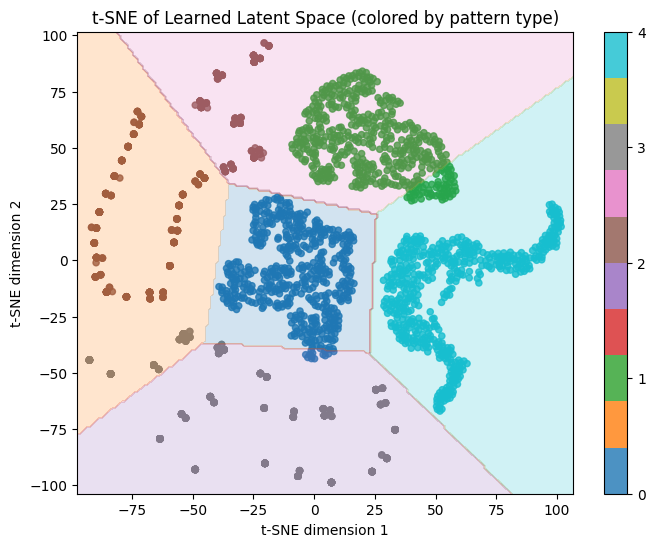

In [7]:
def visualize_tsne(latents, labels, n_clusters=5):
    tsne = TSNE(n_components=2, random_state=42)
    latent_2d = tsne.fit_transform(latents)
    
    plt.figure(figsize=(8,6))
    scatter = plt.scatter(latent_2d[:,0], latent_2d[:,1], c=labels, cmap='tab10', s=20, alpha=0.8)
    plt.colorbar(scatter, ticks=range(n_clusters))
    plt.title("t-SNE of Learned Latent Space (colored by pattern type)")
    
    # 使用 KMeans 分群
    kmeans = KMeans(n_clusters=n_clusters, random_state=42).fit(latent_2d)
    xx, yy = np.meshgrid(np.linspace(latent_2d[:,0].min()-5, latent_2d[:,0].max()+5, 200),
                         np.linspace(latent_2d[:,1].min()-5, latent_2d[:,1].max()+5, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]
    # 將 grid 轉換成與 latent_2d 相同的資料型態
    grid = grid.astype(latent_2d.dtype)
    
    pred_clusters = kmeans.predict(grid).reshape(xx.shape)
    plt.contourf(xx, yy, pred_clusters, alpha=0.2, cmap='tab10')
    
    plt.xlabel("t-SNE dimension 1")
    plt.ylabel("t-SNE dimension 2")
    plt.show()

# 執行提取 latent 與可視化
latent_vectors, labels = extract_latent(model, full_loader, device)
visualize_tsne(latent_vectors, labels, n_clusters=5)